In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("StudentPerformanceFactors.csv")

print("--- TASK 1: DATA LOADED SUCCESSFULLY ---")
print("\n1. First 5 Rows of the Dataset:")
display(df.head())

print("\n2. Dataset Shape (Rows, Columns):", df.shape)
print("\n3. Data Types of Columns:")
print(df.dtypes)

print("\n" + "="*50 + "\n")

print("--- TASK 2: NULL VALUE ANALYSIS ---")
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / df.shape[0]) * 100

null_table = pd.DataFrame({
    'Missing Count': null_counts,
    'Percentage (%)': null_percentages
})
print(null_table)

exceeding_20 = null_table[null_table['Percentage (%)'] > 20]
print("\nColumns exceeding 20% null rate:", list(exceeding_20.index))

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"Filled missing values in '{col}' with Median.")

print("\n" + "="*50 + "\n")

print("--- TASK 3: DUPLICATE DETECTION ---")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully!")
    print(f"New Dataset Shape: {df.shape}")
else:
    print("No duplicates to remove. Dataset is clean.")

--- TASK 1: DATA LOADED SUCCESSFULLY ---

1. First 5 Rows of the Dataset:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



2. Dataset Shape (Rows, Columns): (6607, 20)

3. Data Types of Columns:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


--- TASK 2: NULL VALUE ANALYSIS ---
                            Missing Count  Percentage (%)
Hours_Studied                           0        0.000000
Attendance         

In [11]:
print("--- TASK 4: DATA TYPE CORRECTION ---")
initial_memory = df.memory_usage(deep=True).sum()
print(f"Initial Memory Usage: {initial_memory / 1024:.2f} KB")

categorical_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
                    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
                    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                    'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

final_memory = df.memory_usage(deep=True).sum()
print(f"Final Memory Usage: {final_memory / 1024:.2f} KB")
print(f"Memory Saved: {(initial_memory - final_memory) / 1024:.2f} KB")

print("\n" + "="*50 + "\n")

print("--- TASK 5: DESCRIPTIVE STATISTICS & SKEWNESS ---")
print("\nDescriptive Statistics:")
display(df.describe())

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skew_values = df[numeric_cols].skew()

print("\nSkewness Values:")
print(skew_values)

highest_skew_col = skew_values.abs().idxmax()
highest_skew_val = skew_values[highest_skew_col]
print(f"\nColumn with highest absolute skewness: '{highest_skew_col}' (Value: {highest_skew_val:.4f})")

--- TASK 4: DATA TYPE CORRECTION ---
Initial Memory Usage: 4887.49 KB
Final Memory Usage: 448.49 KB
Memory Saved: 4439.00 KB


--- TASK 5: DESCRIPTIVE STATISTICS & SKEWNESS ---

Descriptive Statistics:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000



Skewness Values:
Hours_Studied        0.013499
Attendance           0.013666
Sleep_Hours         -0.023805
Previous_Scores     -0.003737
Tutoring_Sessions    0.815530
Physical_Activity   -0.031365
Exam_Score           1.644808
dtype: float64

Column with highest absolute skewness: 'Exam_Score' (Value: 1.6448)


In [12]:
print("--- TASK 6: OUTLIER DETECTION WITH IQR ---")

outlier_cols = ['Hours_Studied', 'Tutoring_Sessions']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: '{col}'")
    print(f"  Q1 (25th percentile): {Q1}")
    print(f"  Q3 (75th percentile): {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Lower Bound: {lower_bound}")
    print(f"  Upper Bound: {upper_bound}")
    print(f"  Total Outliers Detected: {len(outliers)} rows")

print("\nNote: Outliers documented but not dropped as per instructions.")

--- TASK 6: OUTLIER DETECTION WITH IQR ---

Column: 'Hours_Studied'
  Q1 (25th percentile): 16.0
  Q3 (75th percentile): 24.0
  IQR: 8.0
  Lower Bound: 4.0
  Upper Bound: 36.0
  Total Outliers Detected: 43 rows

Column: 'Tutoring_Sessions'
  Q1 (25th percentile): 1.0
  Q3 (75th percentile): 2.0
  IQR: 1.0
  Lower Bound: -0.5
  Upper Bound: 3.5
  Total Outliers Detected: 430 rows

Note: Outliers documented but not dropped as per instructions.


--- TASK 7: DATA VISUALIZATION ---

Generating Plot 1: Line Plot of Exam Scores...


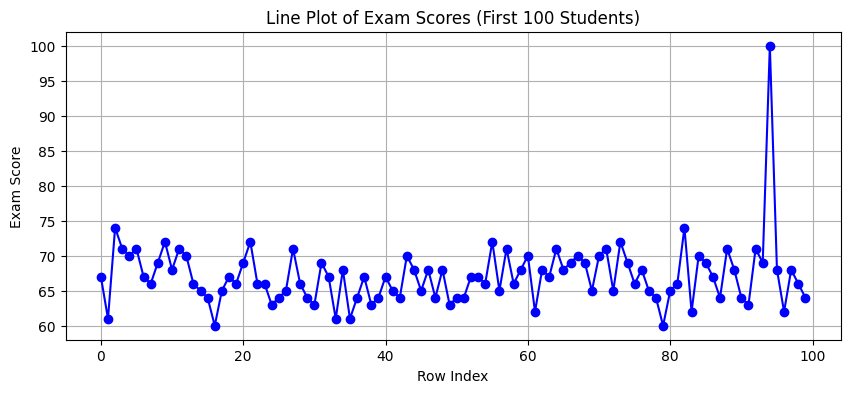


Generating Plot 2: Bar Chart of Average Exam Score by Family Income...


/tmp/ipykernel_2341/3668096639.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Family_Income', y='Exam_Score', data=df, errorbar=None, palette='muted')


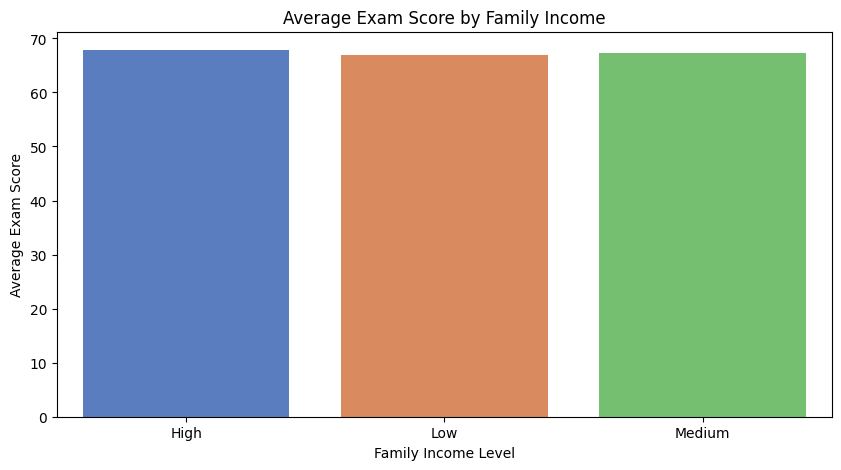


Generating Plot 3: Histogram of Exam Scores (Highest Skewed Column)...


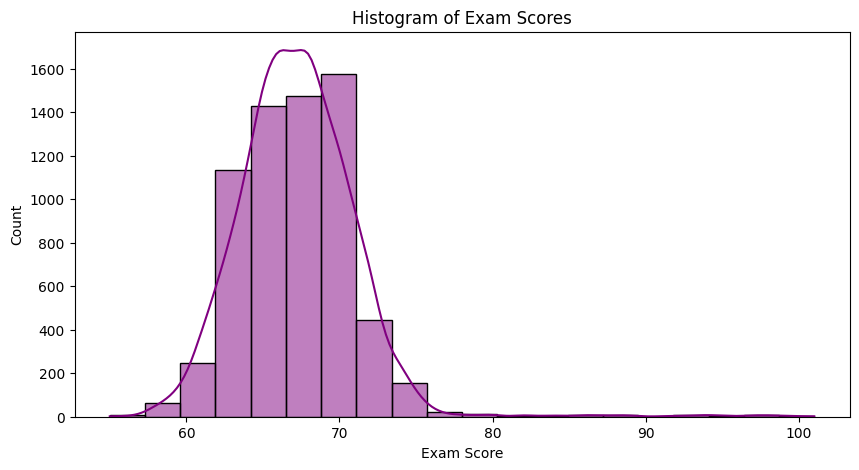


Generating Plot 4: Scatter Plot of Hours Studied vs Exam Score...


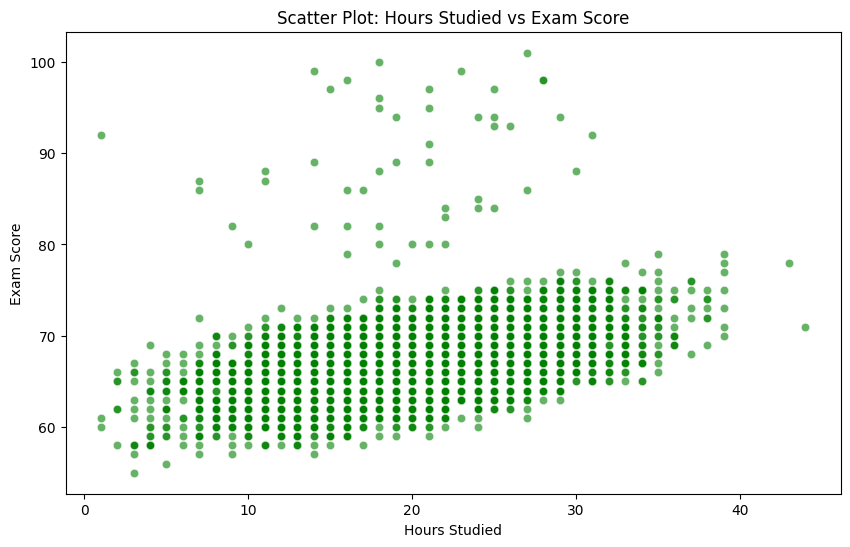


Generating Plot 5: Box Plot of Exam Scores by Parental Involvement...


/tmp/ipykernel_2341/3668096639.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df, palette='pastel')


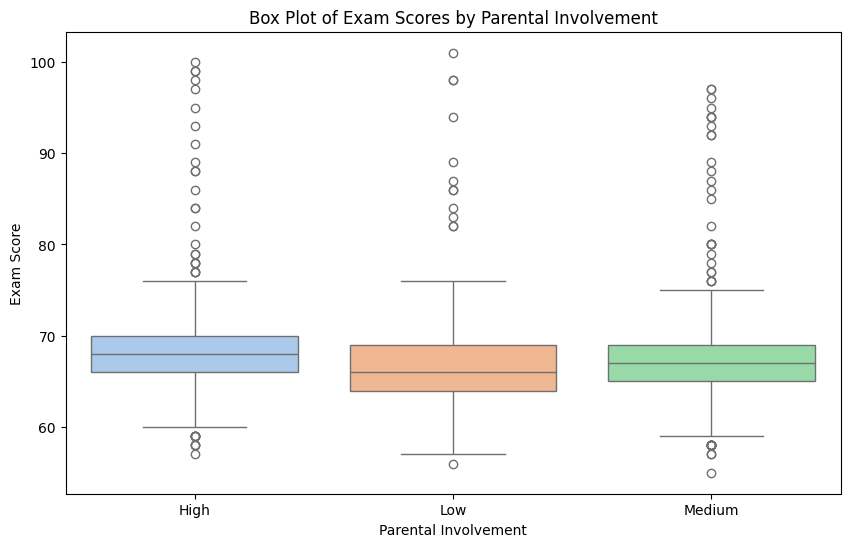

In [13]:
print("--- TASK 7: DATA VISUALIZATION ---")

import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Plot 1: Line Plot of Exam Scores...")
plt.figure(figsize=(10, 4))
plt.plot(df['Exam_Score'].head(100), marker='o', color='blue', linestyle='-')
plt.title('Line Plot of Exam Scores (First 100 Students)')
plt.xlabel('Row Index')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

print("\nGenerating Plot 2: Bar Chart of Average Exam Score by Family Income...")
plt.figure(figsize=(10, 5))
sns.barplot(x='Family_Income', y='Exam_Score', data=df, errorbar=None, palette='muted')
plt.title('Average Exam Score by Family Income')
plt.xlabel('Family Income Level')
plt.ylabel('Average Exam Score')
plt.show()

print("\nGenerating Plot 3: Histogram of Exam Scores (Highest Skewed Column)...")
plt.figure(figsize=(10, 5))
sns.histplot(df['Exam_Score'], bins=20, kde=True, color='purple')
plt.title('Histogram of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.show()

print("\nGenerating Plot 4: Scatter Plot of Hours Studied vs Exam Score...")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.6, color='green')
plt.title('Scatter Plot: Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

print("\nGenerating Plot 5: Box Plot of Exam Scores by Parental Involvement...")
plt.figure(figsize=(10, 6))
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df, palette='pastel')
plt.title('Box Plot of Exam Scores by Parental Involvement')
plt.xlabel('Parental Involvement')
plt.ylabel('Exam Score')
plt.show()

--- POINT 8: CORRELATION HEAT MAP ---

Generating Correlation Heatmap...


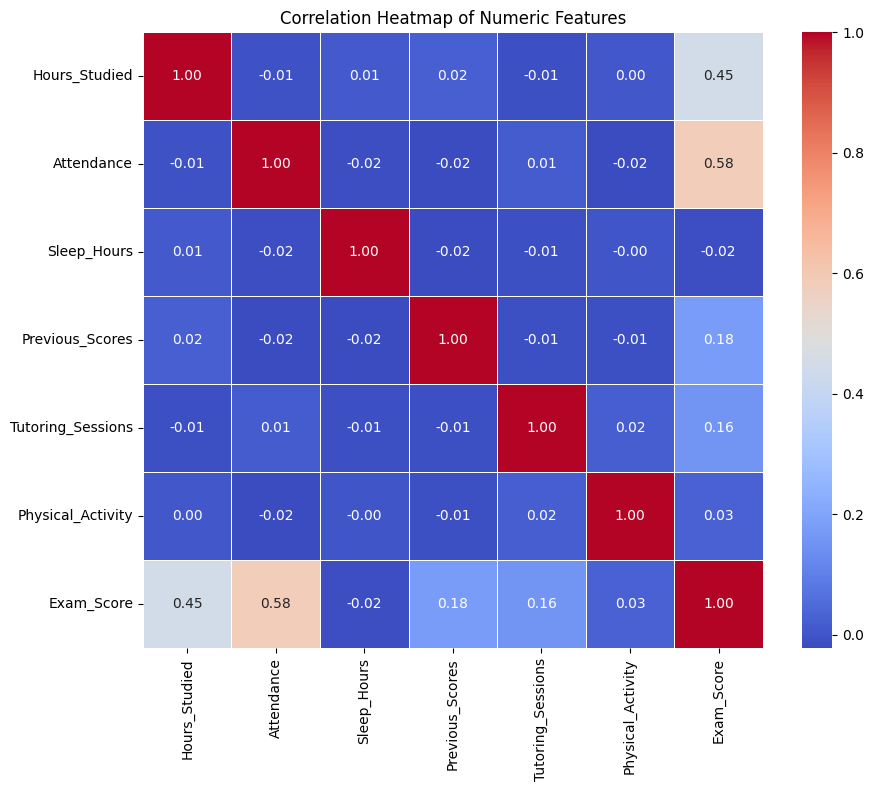

In [14]:
print("--- POINT 8: CORRELATION HEAT MAP ---")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [15]:
print("=== POINT 9: COMPLETE DATA ANALYSIS (a, b, c) ===")

import pandas as pd
import numpy as np

# -------------------------------------------------------------
# 9-a. Imputation Strategy Comparison
# -------------------------------------------------------------
print("\n>>> [9-a] Mean vs Median for Highest Skewed Columns:")
skewed_cols = ['Exam_Score', 'Tutoring_Sessions']
for col in skewed_cols:
    col_mean = df[col].mean()
    col_median = df[col].median()
    print(f"Column '{col}' -> Mean: {col_mean:.4f} | Median: {col_median:.4f}")

# -------------------------------------------------------------
# 9-b. Spearman Rank Correlation
# -------------------------------------------------------------
print("\n>>> [9-b] Spearman Rank Correlation Matrix:")
numeric_df = df.select_dtypes(include=[np.number])
spearman_corr = numeric_df.corr(method='spearman')
print(spearman_corr.round(4))

# -------------------------------------------------------------
# 9-c. Grouped Aggregation
# -------------------------------------------------------------
print("\n>>> [9-c] Grouped Aggregation (Parental Involvement vs Exam Score):")
grouped_result = df.groupby('Parental_Involvement')['Exam_Score'].agg(['mean', 'std', 'count'])
print(grouped_result)

print("\n================================================")
print("--- ALL PARTS OF POINT 9 COMPLETED SUCCESSFULLY ---")

=== POINT 9: COMPLETE DATA ANALYSIS (a, b, c) ===

>>> [9-a] Mean vs Median for Highest Skewed Columns:
Column 'Exam_Score' -> Mean: 67.2357 | Median: 67.0000
Column 'Tutoring_Sessions' -> Mean: 1.4937 | Median: 1.0000

>>> [9-b] Spearman Rank Correlation Matrix:
                   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Hours_Studied             1.0000     -0.0098       0.0112           0.0241   
Attendance               -0.0098      1.0000      -0.0126          -0.0201   
Sleep_Hours               0.0112     -0.0126       1.0000          -0.0223   
Previous_Scores           0.0241     -0.0201      -0.0223           1.0000   
Tutoring_Sessions        -0.0129      0.0148      -0.0061          -0.0182   
Physical_Activity        -0.0026     -0.0242       0.0009          -0.0082   
Exam_Score                0.4810      0.6724      -0.0076           0.1919   

                   Tutoring_Sessions  Physical_Activity  Exam_Score  
Hours_Studied                -0.0129     

/tmp/ipykernel_2341/2417210623.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_result = df.groupby('Parental_Involvement')['Exam_Score'].agg(['mean', 'std', 'count'])


In [16]:
print("--- POINT 10: SAVE THE CLEANED DATASET ---")

output_filename = "cleaned_student_performance.csv"
df.to_csv(output_filename, index=False)

print(f"\nSuccess: Cleaned dataset saved successfully as '{output_filename}'")
print("\n--- ASSIGNMENT COMPLETED ---")

--- POINT 10: SAVE THE CLEANED DATASET ---

Success: Cleaned dataset saved successfully as 'cleaned_student_performance.csv'

--- ASSIGNMENT COMPLETED ---
